In [61]:
using DataFrames
using Distributions
using Plots
using Random
using StatsBase
using Markdown

## Figuring out what distribution and paramaters to use; how to apply to events

### Binomial

98.15
[105, 96, 113, 97, 104, 96, 107, 81, 95, 89, 97, 94, 81, 92, 81, 107, 90, 101, 95, 89, 116, 116, 103, 106, 93, 107, 96, 96, 100, 98, 91, 96, 106, 114, 103, 102, 95, 90, 93, 94, 108, 102, 100, 84, 97, 112, 116, 107, 101, 94, 104, 94, 100, 92, 98, 85, 90, 117, 98, 98, 90, 104, 81, 94, 100, 109, 79, 106, 86, 93, 107, 102, 112, 88, 104, 86, 88, 103, 110, 98, 90, 92, 90, 95, 102, 108, 103, 104, 96, 85, 116, 94, 92, 106, 93, 92, 106, 92, 90, 107]


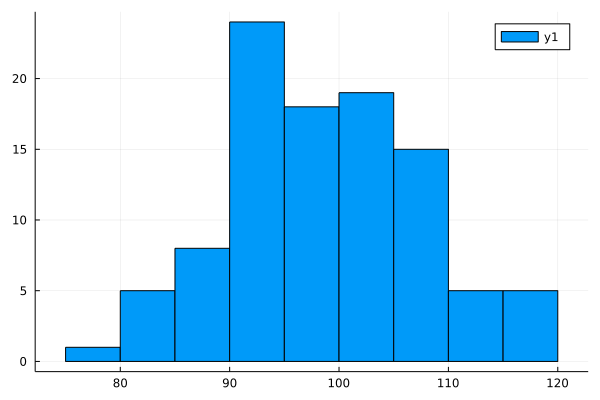

In [26]:
dbin = Binomial(1000,0.1)
x = rand(dbin,100);
println(mean(x))
println(x)
histogram(x, bins=10)

In [27]:
# bin the data
histdata = [count(isequal(i),x) for i in unique(x)]
println(histdata)
# hh = hist(x,22);  # using PyPlot package
# println(hh[1])
# println(hh[2])

[1, 6, 1, 3, 5, 6, 4, 4, 2, 6, 6, 7, 2, 4, 4, 5, 4, 4, 5, 1, 1, 4, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1]


33.49


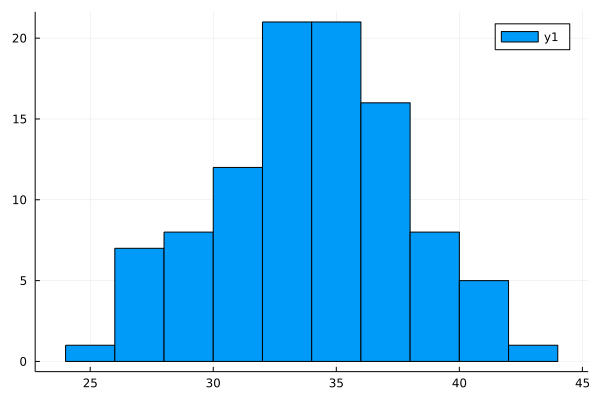

In [6]:
dhypergeo = Hypergeometric(100,200,100) # successes, failures, draws
x = rand(dhypergeo,100)
println(mean(x))
histogram(x,bins=10)

0.953


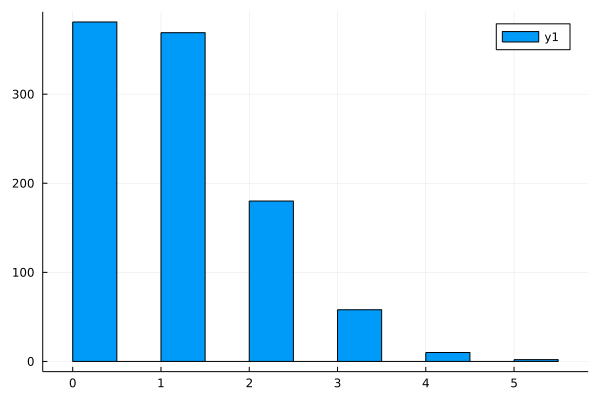

In [10]:
dpoiss = Poisson(1)
x = rand(dpoiss, 1000)
println(mean(x))
histogram(x)

### The long tail of (some) gamma distributions.

3.087900950509001
309.0


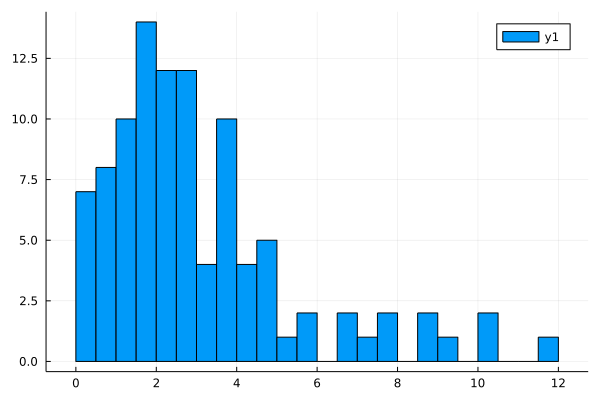

In [11]:
dgamma = Gamma(1.4, 2.0 )  #shape, scale
x = rand(dgamma,100);
println(mean(x))
println(round(sum((x))))
histogram(x, bins=22)
# hh = hist(x,20);  using PyPlot
# println(ceil(sum(hh[1] .* hh[2][2:end])))
# println(mean(dgamma) * 20)

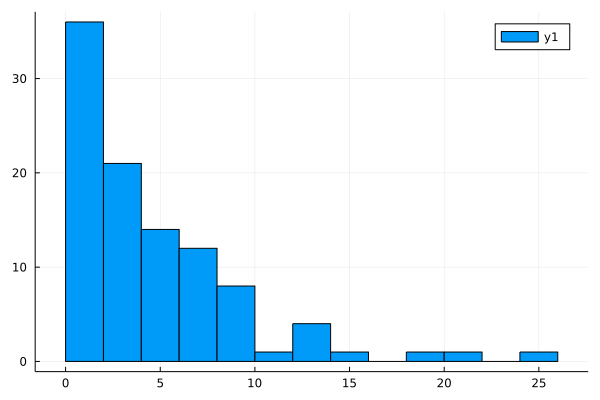

In [15]:
derlang = Erlang(1,5)  # integer shape, scale
x = rand(derlang,100);
histogram(x,bins=22)

In [16]:
println(round.(Int,x))
println(round(mean(x)))

[0, 5, 5, 4, 4, 2, 0, 1, 4, 3, 1, 1, 1, 10, 6, 9, 12, 10, 3, 7, 3, 6, 3, 2, 7, 8, 1, 4, 10, 5, 5, 1, 5, 9, 0, 4, 1, 3, 2, 0, 4, 2, 1, 7, 6, 18, 2, 0, 3, 0, 1, 3, 7, 1, 6, 20, 5, 2, 3, 2, 1, 2, 14, 9, 7, 2, 8, 3, 1, 3, 2, 7, 1, 3, 2, 1, 13, 6, 3, 25, 3, 2, 2, 4, 11, 6, 0, 3, 0, 8, 1, 4, 4, 1, 5, 1, 2, 13, 0, 14]
5.0


### Variations in Gamma Parameters

# Gamma Distribution Parameters


Rows: Shape        Columns: Scale


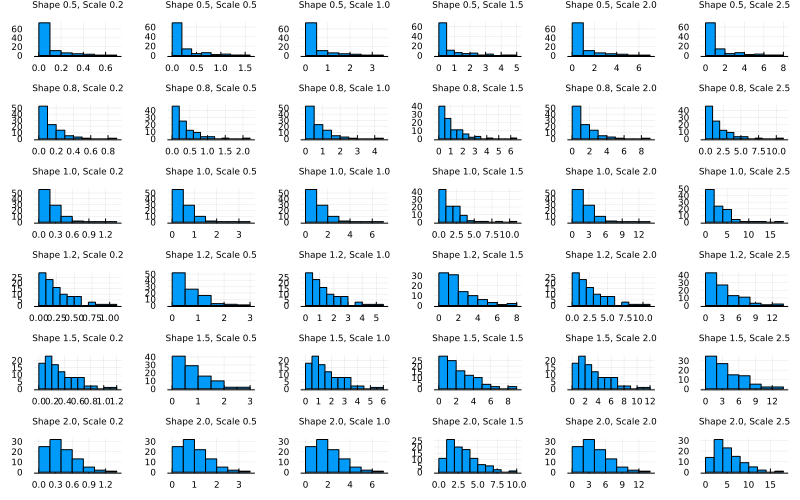

In [65]:
# multiple gamma distributions, varying parameters shape, scale
shapes = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
scales = [0.2, 0.5, 1.0, 1.5, 2.0, 2.5]
p = Array{Any,2}(undef,6,6)
for (shi,sh) in enumerate(shapes)
    for (sci, sc) in enumerate(scales)
        Random.seed!(1)
        dgamma = Gamma(sh, sc)
        x = rand(dgamma,100)
        p[sci,shi] = histogram(x,bins=11,title="Shape $sh, Scale $sc", 
                               titlefontsize=6, size=(800,500))
    end
end
l = @layout([a1 a2 a3 a4 a5 a6; 
             b1 b2 b3 b4 b5 b6; 
             c1 c2 c3 c4 c5 c6; 
             d1 d2 d3 d4 d5 d6; 
             e1 e2 e3 e4 e5 e6; 
             f1 f2 f3 f4 f5 f6])
display(md"# Gamma Distribution Parameters")
display(md"Rows: Shape        Columns: Scale")
plot(p..., layout=l, legend=false, yaxis=false, tickfontsize=6)

### Variations in Erlang Parameters

# Erlang Distribution Parameters


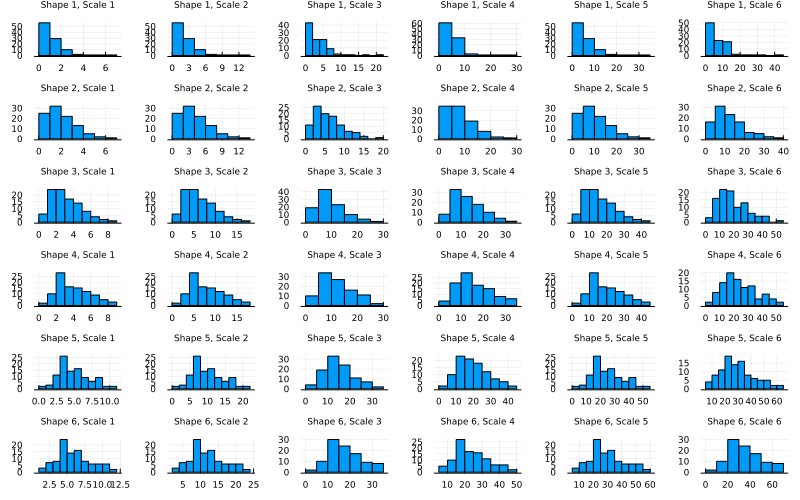

In [64]:
# multiple gamma distributions, varying parameters shape, scale
shapes = [1, 2, 3, 4, 5, 6]
scales = [1, 2, 3, 4, 5, 6]
p = Array{Any,2}(undef,6,6)
for (shi,sh) in enumerate(shapes)
    for (sci, sc) in enumerate(scales)
        Random.seed!(1)
        derlang = Erlang(sh, sc)
        x = rand(derlang,100)
        p[sci,shi] = histogram(x,bins=11,title="Shape $sh, Scale $sc", titlefontsize=6, size=(800,500))
    end
end
l = @layout([a1 a2 a3 a4 a5 a6; 
             b1 b2 b3 b4 b5 b6; 
             c1 c2 c3 c4 c5 c6; 
             d1 d2 d3 d4 d5 d6; 
             e1 e2 e3 e4 e5 e6; 
             f1 f2 f3 f4 f5 f6])

display(md"# Erlang Distribution Parameters")
plot(p..., layout=l, legend=false, yaxis=false, tickfontsize=6)

#### The pdf is a static characteristic of the distribution
So it is always the same result.

In [21]:
dgamma = Gamma(1.2,1.6)
startpoint = 0.5
endpoint = 10
display(pdf.(dgamma,startpoint:endpoint))
println(sum(pdf.(dgamma,startpoint:endpoint)))

10-element Vector{Float64}:
 0.39464853254570686
 0.2631483747149411
 0.15600423592798365
 0.08931572887489385
 0.05027160944702674
 0.028010365338667884
 0.015502254256767219
 0.00853867307419361
 0.004686276044009091
 0.0025648073628812326

1.0126908575870712


In [22]:
dgamma = Gamma(0.5,1.0)
x = rand(0.1:0.1:1.5,6)
rand(dgamma,6)

6-element Vector{Float64}:
 1.0521326860338038
 1.5707907332107627
 0.3052605330032535
 0.12394008769273106
 0.39783509189106114
 0.2106302995471394

In [48]:
methods(fit)

# 24 methods for generic function "fit":
[1] fit(::Type{UnitRangeTransform}, X::AbstractVector{<:Real}; dims, unit) in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/transformations.jl:287
[2] fit(::Type{UnitRangeTransform}, X::AbstractMatrix{<:Real}; dims, unit) in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/transformations.jl:263
[3] fit(::Type{<:Rician}, x::AbstractArray{T}; tol, maxiters) where T in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/continuous/rician.jl:141
[4] fit(::Type{<:Categorical{P} where P<:Real}, data::Tuple{Int64, AbstractArray}) in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/discrete/categorical.jl:173
[5] fit(::Type{<:Categorical{P} where P<:Real}, data::Tuple{Int64, AbstractArray}, w::AbstractArray{Float64}) in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/discrete/categorical.jl:174
[6] fit(::Type{<:Cauchy}, x::AbstractArray{T}) where T<:Real in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/continuous/cauchy.jl:110
[7] fit(::Type{<:Beta}, x::AbstractArray{T}) where T<:Real in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/continuous/beta.jl:248
[8] fit(::Type{T}, data::Tuple{Int64, AbstractArray}) where T<:Binomial in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/discrete/binomial.jl:204
[9] fit(::Type{T}, data::Tuple{Int64, AbstractArray}, w::AbstractArray{<:Real}) where T<:Binomial in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/univariate/discrete/binomial.jl:205
[10] fit(dt::Type{D}, x) where D<:Distribution in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/genericfit.jl:33
[11] fit(dt::Type{D}, args...) where D<:Distribution in Distributions at /Users/lewis/.julia/packages/Distributions/FRKZ0/src/genericfit.jl:34
[12] fit(::Type{ZScoreTransform}, X::AbstractVector{<:Real}; dims, center, scale) in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/transformations.jl:130
[13] fit(::Type{ZScoreTransform}, X::AbstractMatrix{<:Real}; dims, center, scale) in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/transformations.jl:109
[14] fit(::Type{Histogram}, vs::Tuple{Vararg{AbstractVector, N}}, wv::AbstractWeights{W, T} where T<:Real, args...; kwargs...) where {N, W} in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:408
[15] fit(::Type{Histogram{T}}, vs::Tuple{Vararg{AbstractVector, N}}; closed, nbins) where {T, N} in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:356
[16] fit(::Type{Histogram{T}}, vs::Tuple{Vararg{AbstractVector, N}}, wv::AbstractWeights; closed, nbins) where {T, N} in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:362
[17] fit(::Type{Histogram{T}}, vs::Tuple{Vararg{AbstractVector, N}}, wv::AbstractWeights{W, T} where T<:Real, edges::Tuple{Vararg{AbstractVector, N}}; closed) where {T, N, W} in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:359
[18] fit(::Type{Histogram{T}}, vs::Tuple{Vararg{AbstractVector, N}}, edges::Tuple{Vararg{AbstractVector, N}}; closed) where {T, N} in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:353
[19] fit(::Type{Histogram}, v::AbstractVector, wv::AbstractWeights{W, T} where T<:Real, args...; kwargs...) where W in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:307
[20] fit(::Type{Histogram{T}}, v::AbstractVector; closed, nbins) where T in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:300
[21] fit(::Type{Histogram{T}}, v::AbstractVector, wv::AbstractWeights; closed, nbins) where T in StatsBase at /Users/lewis/.julia/packages/StatsBase/XgjIN/src/hist.jl:304
[22] fit(::Type{Histogram{T}}, v::AbstractVector, wv::AbstractWeights, edg::AbstractVector; closed) where T in StatsBase at /Users/le

In [57]:
nilprobs = [.6, 0.0, .1, .1, 0.1, 0.1]

dcat = Categorical(nilprobs)
x = rand(dcat,100)
println(x)
println([count(x->x==i, x) for i in 1:6])
hh = fit(Histogram, x, nbins=6)
println(fieldnames(typeof(hh)))
println(hh.weights)
println(length(hh.weights))
println(hh.edges)

[1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 5, 5, 1, 4, 1, 1, 1, 1, 6, 1, 1, 1, 6, 1, 1, 6, 1, 6, 1, 6, 1, 6, 1, 5, 1, 1, 1, 1, 1, 1, 3, 1, 1, 3, 3, 1, 3, 1, 6, 6, 4, 1, 1, 1, 1, 1, 4, 5, 6, 1, 4, 1, 1, 1, 6, 1, 6, 3, 1, 6, 1, 4, 5, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 1, 5, 6, 1, 1, 1, 1, 3, 1, 1, 5, 5, 1]
[63, 0, 10, 6, 8, 13]
(:edges, :weights, :closed, :isdensity)
[63, 0, 10, 6, 8, 13]
6
(1.0:1.0:7.0,)


## Categorical Distribution

### Here is the categorical distribution output with 3 classes (well, 6 with 3 having 0.0 probability) with 100 trials. Next, we will try with similar inputs using the multinomial probability distribution.

In [ ]:
snorm(arr) = arr ./ (sum(arr))

age_amplify = Dict(1=>(1.3,.7), 2=>(1.1,.9), 3=>(1.0, 1.0), 4=>(0.9,1.1), 5=>(.8,1.2))
nilprobs = [.6, 0.0, .3, .1, 0.0, 0.0]
# do we amplify the probs or the outcomes?
# probs
nilprobs = snorm(nilprobs .* [0.8, 0.0, 1.2, 1.2, 0.0, 0.0])
# all this does is jiggle things in a way that doesn't have a lot of meaning--it changes the relative probs in 
# partially obvious way.  We need a reason that justifies the math.

probs = nilprobs
println(probs)

dcat = Categorical(probs)
x = rand(dcat,100)
vals = [count(x .== i) for i in 1:6]
# names = ("cat 1", "cat 2", "cat 3", "cat 4", "cat 5", "cat 6")
# bar(names, vals);
println(x)
println(vals)
histogram(x,bins=10, xaxis=(lims=(1,10)))

In [ ]:
# use the modified probs from the above to compare distribution plots
probs = [0.5, 0.0, 0.375, 0.125, 0.0, 0.0]
dmulti = Multinomial(100, probs)
names = ("cat 1", "cat 2", "cat 3", "cat 4", "cat 5", "cat 6")
x = vec(rand(dmulti, 1))
println(x)
bar(names, x);
# xlim(0.0,6.0)

### Let's try this again with a simpler approach:

In [ ]:
probs = [0.5, 0.0, 0.375, 0.125, 0.0, 0.0]
cats = 6
boundaries = [0.0, probs[1], sum(probs[1:2]), sum(probs[1:3]), sum(probs[1:4]), sum(probs[1:5]), sum(probs[1:6])]
println(boundaries)
x = rand(100)
counts = [count(boundaries[i-1] .<= x .< boundaries[i]) for i in 2:7]
names = ("cat 1", "cat 2", "cat 3", "cat 4", "cat 5", "cat 6")
println(counts)
bar(names, counts);

In [ ]:
dbin1 = Binomial(100,0.5)
dbin3 = Binomial(100, 0.15)
dbin4 = Binomial(100, 0.05)

x1 = rand(dbin1, 100)
x3 = rand(dbin3, 100)
x4 = rand(dbin4, 100)

println(x1)
println(x3)
println(x4)

p1 = histogram(x1)
p3 = histogram(x3)
p4 = histogram(x4)

plot(p1,p3,p4,layout=@layout([a;b;c]),size=(400,700))

In [ ]:
hist(rand(dbin1,1000));

In [ ]:
dbin5 = Binomial(1,0.6)
x = rand(dbin5, 100)
println(sum(x))